# DoRA Implementation: LLaMA2-7B


## Environment Setup

In [2]:
!pip install ipython==8.12.0

In [3]:
!pip install datasets
!pip install einops
!pip install transformers

In [4]:
# %pip install -q --no-cache-dir --upgrade-strategy only-if-needed \
#   "transformers==4.44.2" \
#   "accelerate==0.34.2" \
#   "datasets==2.21.0" \
#   "sentencepiece" \
#   "safetensors" \
#   "tqdm"

%pip install -q --no-cache-dir \
  "transformers==4.44.2" \
  "accelerate==0.34.2" \
  "datasets==2.21.0" \
  "fsspec==2024.6.1" \
  "gcsfs==2024.6.1" \
  sentencepiece safetensors tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 865.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 272.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 891.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 917.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 396.3 MB/s eta 0:00:00


In [5]:
%pip install -U torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [6]:
from google.colab import drive
try:
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive mount skipped or unavailable:', exc)

Mounted at /content/drive


In [7]:
from pathlib import Path
import gc
import json
import math
import os
import random
import re
import time
from dataclasses import dataclass
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, get_linear_schedule_with_warmup

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cuda.matmul.allow_tf32 = True
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition


## Configuration

Point `DORA_ROOT` to the folder containing `datasets/`. In Colab, upload/copy the Desktop `DoRA` folder to `/content/DoRA` or Google Drive and edit the path below. Set `BASE_MODEL` to your accessible LLaMA-7B Hugging Face path or local checkpoint.

In [8]:
# Path containing datasets/boolq, datasets/piqa, etc.
DORA_ROOT = Path('/content/DoRA')
if not (DORA_ROOT / 'datasets').exists():
    # Set root directory
    DORA_ROOT = Path('/content/drive/MyDrive/DoRA')

DATA_ROOT = DORA_ROOT / 'datasets'
# PEFT_ROOT = DORA_ROOT / 'peft/src'
OUTPUT_ROOT = DORA_ROOT / 'outputs_table15_0430'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Base Model configuration

# BASE_MODEL = 'yahma/llama-13b-hf'
BASE_MODEL = 'meta-llama/Llama-2-7b-hf'
# BASE_MODEL = 'meta-llama/Meta-Llama-3-8B'
# BASE_MODEL = "yahma/llama-7b-hf"

# Base experiment target
RUN_RANKS = [16, 32]

# target modules Q,K,V,Up,Down
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'up_proj', 'down_proj']


EPOCHS = 3
WARMUP_STEPS = 100
DROPOUT = 0.05
MAX_LENGTH = 256
MICRO_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 16

WEIGHT_DECAY = 0.0
MAX_GRAD_NORM = 1.0

# Keep these truncation settings for your compute-constrained run.
# Set both to None only for full paper-style reproduction.
MAX_TRAIN_SAMPLES = 10000
MAX_EVAL_SAMPLES = 200

# This global LR is kept only for legacy helper functions.
# The main EXPERIMENTS scheduler should provide method-specific LR.
LEARNING_RATE = 2e-4

TASK_DIRS = {
    'BoolQ': 'boolq',
    'PIQA': 'piqa',
    'SIQA': 'social_i_qa',
    'HellaSwag': 'hellaswag',
    'WinoGrande': 'winogrande',
    'ARC-e': 'ARC-Easy',
    'ARC-c': 'ARC-Challenge',
    'OBQA': 'openbookqa',
}

print('DORA_ROOT:', DORA_ROOT)
print('DATA_ROOT exists:', DATA_ROOT.exists())
print('OUTPUT_ROOT:', OUTPUT_ROOT)

print('RUN_RANKS:', RUN_RANKS)
print('TARGET_MODULES:', TARGET_MODULES)
print('MAX_TRAIN_SAMPLES:', MAX_TRAIN_SAMPLES)
print('MAX_EVAL_SAMPLES:', MAX_EVAL_SAMPLES)

DORA_ROOT: /content/drive/MyDrive/DoRA
DATA_ROOT exists: True
OUTPUT_ROOT: /content/drive/MyDrive/DoRA/outputs_table15_0430
RUN_RANKS: [16, 32]
TARGET_MODULES: ['q_proj', 'k_proj', 'v_proj', 'up_proj', 'down_proj']
MAX_TRAIN_SAMPLES: 10000
MAX_EVAL_SAMPLES: 200


### Smoketesting Configuration -- sanity check before formal experiment

Skip this cell in formal experiments!

In [ ]:
SMOKE_TEST_MODE = True

if SMOKE_TEST_MODE:
    RUN_RANKS = [16]

    # Keep the paper commonsense target modules.
    TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'up_proj', 'down_proj']

    # Tiny compute settings for pipeline validation.
    MAX_TRAIN_SAMPLES = 64
    MAX_EVAL_SAMPLES = 16

    EPOCHS = 1
    WARMUP_STEPS = 2
    MICRO_BATCH_SIZE = 1
    GRADIENT_ACCUMULATION_STEPS = 4

    print('⚠️ Smoke-test override is active.')
    print('RUN_RANKS:', RUN_RANKS)
    print('TARGET_MODULES:', TARGET_MODULES)
    print('MAX_TRAIN_SAMPLES:', MAX_TRAIN_SAMPLES)
    print('MAX_EVAL_SAMPLES:', MAX_EVAL_SAMPLES)
    print('EPOCHS:', EPOCHS)
    print('WARMUP_STEPS:', WARMUP_STEPS)
    print('MICRO_BATCH_SIZE:', MICRO_BATCH_SIZE)
    print('GRADIENT_ACCUMULATION_STEPS:', GRADIENT_ACCUMULATION_STEPS)

⚠️ Smoke-test override is active.
RUN_RANKS: [16]
TARGET_MODULES: ['q_proj', 'k_proj', 'v_proj', 'up_proj', 'down_proj']
MAX_TRAIN_SAMPLES: 64
MAX_EVAL_SAMPLES: 16
EPOCHS: 1
WARMUP_STEPS: 2
MICRO_BATCH_SIZE: 1
GRADIENT_ACCUMULATION_STEPS: 4


## Dataset loading and prompt formatting

The local dataset files are already instruction formatted. Training uses `instruction + output`. Evaluation builds the same instruction prefix and scores each allowed answer from `Answer format: ...`.

In [9]:
def load_json_list(path: Path) -> List[dict]:
    with path.open('r', encoding='utf-8') as f:
        data = json.load(f)
    if not isinstance(data, list):
        raise ValueError(f'{path} must contain a JSON list')
    return data


def example_prompt(example: dict) -> str:
    instruction = str(example.get('instruction', '')).strip()
    extra_input = str(example.get('input', '')).strip()
    if extra_input:
        instruction = instruction + '\n\n' + extra_input
    return '### Instruction:\n' + instruction + '\n\n### Response:\n'


def example_train_text(example: dict, tokenizer) -> str:
    return example_prompt(example) + str(example['output']).strip() + tokenizer.eos_token


def extract_choices(instruction: str) -> List[str]:
    match = re.search(r'Answer format:\s*([^\n]+)', instruction, flags=re.IGNORECASE)
    if not match:
        raise ValueError('Could not find Answer format in instruction: ' + instruction[:200])
    raw = match.group(1).strip()
    choices = [c.strip().lower() for c in raw.split('/') if c.strip()]
    if not choices:
        raise ValueError('No choices parsed from: ' + raw)
    return choices


def canonical_answer(answer: str) -> str:
    answer = str(answer).strip().lower()
    # Handles strings such as 'the correct answer is answer1'.
    if 'the correct answer is ' in answer:
        answer = answer.split('the correct answer is ', 1)[1].strip()
    return answer.split()[0].strip('.,;:')


def load_all_train_examples() -> List[dict]:
    examples = []
    for task, dirname in TASK_DIRS.items():
        path = DATA_ROOT / dirname / 'train.json'
        task_examples = load_json_list(path)
        for ex in task_examples:
            ex = dict(ex)
            ex['task'] = task
            examples.append(ex)
        print(f'{task:10s} train: {len(task_examples):6d}')
    random.Random(SEED).shuffle(examples)
    if MAX_TRAIN_SAMPLES is not None:
        examples = examples[:MAX_TRAIN_SAMPLES]
    print('Total train examples:', len(examples))
    return examples


def load_eval_examples(task: str) -> List[dict]:
    path = DATA_ROOT / TASK_DIRS[task] / 'test.json'
    examples = load_json_list(path)
    if MAX_EVAL_SAMPLES is not None:
        examples = examples[:MAX_EVAL_SAMPLES]
    return examples

# Show schema sanity.
for task, dirname in TASK_DIRS.items():
    sample = load_json_list(DATA_ROOT / dirname / 'train.json')[0]
    print('\n', task, sample.keys())
    print(sample['instruction'][:240].replace('\n', ' '))
    print('choices:', extract_choices(sample['instruction']), 'answer:', canonical_answer(sample['answer']))


 BoolQ dict_keys(['instruction', 'input', 'output', 'answer'])
Please answer the following question with true or false, question: do iran and afghanistan speak the same language?  Answer format: true/false
choices: ['true', 'false'] answer: true

 PIQA dict_keys(['instruction', 'input', 'output', 'answer'])
Please choose the correct solution to the question: When boiling butter, when it's ready, you can  Solution1: Pour it onto a plate  Solution2: Pour it into a jar  Answer format: solution1/solution2
choices: ['solution1', 'solution2'] answer: solution2

 SIQA dict_keys(['instruction', 'input', 'output', 'answer'])
Please choose the correct answer to the question: Cameron decided to have a barbecue and gathered her friends together. How would Others feel as a result?  Answer1: like attending Answer2: like staying home Answer3: a good friend to have  A
choices: ['answer1', 'answer2', 'answer3'] answer: answer1

 HellaSwag dict_keys(['instruction', 'input', 'output', 'answer'])
Please 

In [10]:
class SFTDataset(Dataset):
    def __init__(self, examples: Sequence[dict], tokenizer, max_length: int):
        self.examples = list(examples)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        example = self.examples[idx]

        prompt = example_prompt(example)
        full_text = prompt + str(example['output']).strip() + self.tokenizer.eos_token

        enc = self.tokenizer(
            full_text,
            truncation=True,
            max_length=self.max_length,
            padding=False,
            add_special_tokens=False
        )
        input_ids = enc['input_ids']
        attention_mask = enc['attention_mask']

        prompt_len = len(self.tokenizer(prompt, add_special_tokens=False)['input_ids'])

        labels = input_ids.copy()
        mask_len = min(prompt_len, len(labels))
        labels[:mask_len] = [-100] * mask_len

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels
        }


def make_collator(tokenizer):
    def collate(batch):
        max_len = max(len(x['input_ids']) for x in batch)
        input_ids, attention_mask, labels = [], [], []

        for item in batch:
            pad_len = max_len - len(item['input_ids'])

            # input_ids 用 pad_token_id 填充
            input_ids.append(item['input_ids'] + [tokenizer.pad_token_id] * pad_len)
            # attention_mask 用 0 填充
            attention_mask.append(item['attention_mask'] + [0] * pad_len)
            # labels 用 -100 填充（Padding 部分同样不参与 Loss 计算）
            labels.append(item['labels'] + [-100] * pad_len)

        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
            'labels': torch.tensor(labels, dtype=torch.long)
        }
    return collate

### Hugging Face Login

To access gated models like `meta-llama/Llama-2-7b-hf`, you need to log in to Hugging Face. You can generate a Hugging Face token from your [Hugging Face settings page](https://huggingface.co/settings/tokens).

In [11]:
from huggingface_hub import login

login()

### Masking Smoketest

In [ ]:
def load_tokenizer(base_model: str):
    tokenizer = AutoTokenizer.from_pretrained(base_model, use_fast=False)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = 'right'
    return tokenizer


def run_dataset_mask_smoketest(tokenizer):
    print("Running dataset mask smoke test...")

    ex = {
        "instruction": "Choose one. Answer format: answer1/answer2",
        "input": "",
        "output": "the correct answer is answer1",
        "answer": "answer1",
    }

    ds = SFTDataset([ex], tokenizer, max_length=128)
    item = ds[0]

    prompt = example_prompt(ex)
    prompt_len = len(tokenizer(prompt, add_special_tokens=False)["input_ids"])

    labels = item["labels"]

    assert all(x == -100 for x in labels[:prompt_len]), "Prompt tokens are not fully masked"
    assert any(x != -100 for x in labels[prompt_len:]), "Completion tokens are all masked"
    assert len(item["input_ids"]) == len(item["attention_mask"]) == len(item["labels"])

    print("✅ Dataset mask smoke test passed.")


tokenizer = load_tokenizer(BASE_MODEL)
run_dataset_mask_smoketest(tokenizer)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Running dataset mask smoke test...
✅ Dataset mask smoke test passed.


## DoRA from scratch

For a frozen pretrained weight `W0`, DoRA trains a magnitude vector `m` and low-rank direction update `BA`:

$$W' = m \frac{W_0 + BA}{\lVert W_0 + BA \rVert_c}$$

PyTorch `Linear` stores weights as `(out_features, in_features)`, so this implementation normalizes each output row. This is equivalent to column-wise normalization under the transposed convention used by `F.linear`.

In [12]:
class DoRALinear(nn.Module):
    def __init__(self, base: nn.Linear, rank: int, alpha: int, dropout: float):
        super().__init__()
        self.in_features = base.in_features
        self.out_features = base.out_features
        self.rank = rank
        self.alpha = alpha
        self.scaling = alpha / rank
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        # Freeze Original Weights
        self.weight = nn.Parameter(base.weight.detach().clone(), requires_grad=False)
        self.bias = nn.Parameter(base.bias.detach().clone(), requires_grad=False) if base.bias is not None else None

        # LoRA Parameters
        self.lora_A = nn.Parameter(torch.empty(rank, self.in_features, device=self.weight.device, dtype=self.weight.dtype))
        self.lora_B = nn.Parameter(torch.zeros(self.out_features, rank, device=self.weight.device, dtype=self.weight.dtype))
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

        # Magnitude Parameters
        magnitude = torch.linalg.vector_norm(self.weight.float(), ord=2, dim=1).to(self.weight.dtype)
        self.magnitude = nn.Parameter(magnitude)

    def merged_weight(self):
        """Merge weight for inference time"""
        directional = self.weight + self.scaling * (self.lora_B @ self.lora_A)
        norm = torch.linalg.vector_norm(directional.float(), ord=2, dim=1, keepdim=True).to(directional.dtype).clamp_min(1e-6)
        return self.magnitude[:, None] * directional / norm

    def forward(self, x):
        if self.training:

            directional = self.weight + self.scaling * (self.lora_B @ self.lora_A)
            norm = torch.linalg.vector_norm(directional.float(), ord=2, dim=1).to(directional.dtype).clamp_min(1e-6)
            norm_scale = self.magnitude / norm.detach()

            base_out = F.linear(x, self.weight, self.bias)
            lora_out = F.linear(
                F.linear(self.dropout(x), self.lora_A),
                self.lora_B
            ) * self.scaling

            return norm_scale * (base_out + lora_out)
        else:
            return F.linear(self.dropout(x), self.merged_weight(), self.bias)


def replace_target_linears_with_dora(model: nn.Module, target_modules: Iterable[str], rank: int, alpha: int, dropout: float) -> int:
    modules = dict(model.named_modules())
    replacements = []
    target_modules = tuple(target_modules)
    for name, module in modules.items():
        if isinstance(module, nn.Linear) and any(target == name.split('.')[-1] or target in name for target in target_modules):
            parent_name, child_name = name.rsplit('.', 1) if '.' in name else ('', name)
            parent = modules[parent_name] if parent_name else model
            replacements.append((parent, child_name, name))
    for parent, child_name, full_name in replacements:
        old = getattr(parent, child_name)
        setattr(parent, child_name, DoRALinear(old, rank=rank, alpha=alpha, dropout=dropout))
    return len(replacements)


def freeze_all_then_unfreeze_dora(model: nn.Module):
    for p in model.parameters():
        p.requires_grad = False
    for module in model.modules():
        if isinstance(module, DoRALinear):
            module.lora_A.requires_grad = True
            module.lora_B.requires_grad = True
            module.magnitude.requires_grad = True


def trainable_parameter_summary(model: nn.Module) -> Tuple[int, int, float]:
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    return trainable, total, 100.0 * trainable / total

# Tiny startup identity test.
_test = nn.Linear(7, 4, bias=False)
_wrap = DoRALinear(_test, rank=2, alpha=4, dropout=0.0)
_x = torch.randn(3, 7)
with torch.no_grad():
    assert torch.allclose(_test(_x), _wrap(_x), atol=1e-5)
print('DoRALinear startup identity test passed.')

DoRALinear startup identity test passed.


### Smoketest sanity check

In [ ]:
def run_minimal_dora_smoketest():
    print("Running minimal DoRA smoke test...")

    # Use CPU float32 for deterministic identity checks.
    # bf16/fp16 can introduce ~1e-3 rounding error in merged_weight().
    torch.manual_seed(0)
    device = "cpu"
    dtype = torch.float32
    atol = 1e-5
    rtol = 1e-5

    base = nn.Linear(7, 4, bias=False, device=device, dtype=dtype)
    dora = DoRALinear(base, rank=2, alpha=4, dropout=0.0).to(device=device, dtype=dtype)

    x = torch.randn(3, 7, device=device, dtype=dtype)

    dora.train()
    with torch.no_grad():
        y_base = base(x)
        y_dora_train = dora(x)

    dora.eval()
    with torch.no_grad():
        y_dora_eval = dora(x)

    print("max train diff:", (y_base - y_dora_train).abs().max().item())
    print("max eval diff:", (y_base - y_dora_eval).abs().max().item())

    assert torch.allclose(y_base, y_dora_train, atol=atol, rtol=rtol), "Train-mode identity failed"
    assert torch.allclose(y_base, y_dora_eval, atol=atol, rtol=rtol), "Eval merged-weight identity failed"


## Model loading

This loads LLaMA-7B in fp16/bf16 and then replaces target modules with DoRA. The base weights stay frozen, so only DoRA `A`, `B`, and `magnitude` train.

In [13]:
def load_tokenizer(base_model: str):
    tokenizer = AutoTokenizer.from_pretrained(base_model, use_fast=False)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = 'right'
    return tokenizer


def load_dora_model(base_model: str, rank: int):
    dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
    model = AutoModelForCausalLM.from_pretrained(
        base_model,
        torch_dtype=dtype,
        device_map='auto',
        low_cpu_mem_usage=True,
    )
    if hasattr(model, 'config'):
        model.config.use_cache = False
    model.gradient_checkpointing_enable()
    if hasattr(model, 'enable_input_require_grads'):
        model.enable_input_require_grads()

    alpha = 2 * rank
    replaced = replace_target_linears_with_dora(model, TARGET_MODULES, rank=rank, alpha=alpha, dropout=DROPOUT)
    freeze_all_then_unfreeze_dora(model)
    trainable, total, pct = trainable_parameter_summary(model)
    print(f'Rank {rank}: replaced {replaced} linear layers')
    print(f'Rank {rank}: trainable {trainable:,} / {total:,} = {pct:.2f}%')
    return model

## Training loop

This is a plain PyTorch loop, not PEFT/DoRA library code. It matches the paper hyperparameters as closely as possible for LLaMA-7B Table 8: AdamW, LR `2e-4`, linear schedule, warmup `100`, epochs `3`, dropout `0.05`, and effective batch size `16`.

In [14]:
def save_dora_adapter(model: nn.Module, path: Path, rank: int):
    path.parent.mkdir(parents=True, exist_ok=True)
    state = {}
    for name, module in model.named_modules():
        if isinstance(module, DoRALinear):
            state[name + '.lora_A'] = module.lora_A.detach().cpu()
            state[name + '.lora_B'] = module.lora_B.detach().cpu()
            state[name + '.magnitude'] = module.magnitude.detach().cpu()
    torch.save({'rank': rank, 'alpha': 2 * rank, 'target_modules': TARGET_MODULES, 'state_dict': state}, path)
    print('Saved adapter:', path)


def train_one_rank(rank: int, tokenizer) -> nn.Module:
    train_examples = load_all_train_examples()
    dataset = SFTDataset(train_examples, tokenizer, MAX_LENGTH)
    loader = DataLoader(dataset, batch_size=MICRO_BATCH_SIZE, shuffle=True, collate_fn=make_collator(tokenizer), num_workers=2, pin_memory=True)

    model = load_dora_model(BASE_MODEL, rank)
    model.train()

    optimizer = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    update_steps_per_epoch = math.ceil(len(loader) / GRADIENT_ACCUMULATION_STEPS)
    total_update_steps = EPOCHS * update_steps_per_epoch
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=total_update_steps)

    global_step = 0
    running = 0.0
    start = time.time()
    optimizer.zero_grad(set_to_none=True)

    for epoch in range(EPOCHS):
        pbar = tqdm(loader, desc=f'rank {rank} epoch {epoch + 1}/{EPOCHS}')
        for step, batch in enumerate(pbar):
            batch = {k: v.to(model.device) for k, v in batch.items()}
            out = model(**batch)
            loss = out.loss / GRADIENT_ACCUMULATION_STEPS
            loss.backward()
            running += float(loss.detach().cpu())

            if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (step + 1) == len(loader):
                torch.nn.utils.clip_grad_norm_((p for p in model.parameters() if p.requires_grad), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                global_step += 1
                if global_step % 10 == 0:
                    pbar.set_postfix({'loss': running / 10, 'lr': scheduler.get_last_lr()[0]})
                    running = 0.0

    print(f'Rank {rank} training finished in {(time.time() - start) / 60:.1f} min, updates={global_step}')
    model_tag = BASE_MODEL.split("/")[-1].replace("-", "_")
    save_dora_adapter(model, OUTPUT_ROOT / f'dora_{model_tag}_rank{rank}.pt', rank)
    return model

## Multiple-choice evaluation

For every candidate in the example's `Answer format`, this evaluates the conditional negative log likelihood of the completion `the correct answer is <candidate>`. The selected answer is the candidate with the lowest completion loss.

In [15]:
from transformers import GenerationConfig


TASK_PATTERNS = {
    'BoolQ': re.compile(r'\b(?:true|false)\b', re.IGNORECASE),
    'PIQA': re.compile(r'\b(?:solution1|solution2)\b', re.IGNORECASE),
    'SIQA': re.compile(r'\b(?:answer1|answer2|answer3)\b', re.IGNORECASE),
    'HellaSwag': re.compile(r'\b(?:ending1|ending2|ending3|ending4)\b', re.IGNORECASE),
    'WinoGrande': re.compile(r'\b(?:option1|option2)\b', re.IGNORECASE),
    'ARC-e': re.compile(r'\b(?:answer1|answer2|answer3|answer4)\b', re.IGNORECASE),
    'ARC-c': re.compile(r'\b(?:answer1|answer2|answer3|answer4)\b', re.IGNORECASE),
    'OBQA': re.compile(r'\b(?:answer1|answer2|answer3|answer4)\b', re.IGNORECASE),
}


def build_commonsense_prompt(example: dict, task: str) -> str:
    """Use the Hu/DoRA commonsense instruction directly, without an Alpaca wrapper."""
    instruction = str(example['instruction']).strip()
    input_text = str(example.get('input', '')).strip()
    if input_text:
        instruction = instruction + '\n\n' + input_text
    return instruction + '\n\nthe correct answer is'


def extract_generated_answer(task: str, text: str) -> str:
    pattern = TASK_PATTERNS.get(task)
    if pattern is None:
        raise ValueError(f'Unsupported task for answer extraction: {task}')
    match = pattern.search(str(text).strip().lower())
    return match.group(0).lower() if match else ''


def generate_predictions(
    model,
    tokenizer,
    prompts: List[str],
    batch_size: int = 1,
    max_input_length: int = None,
    max_new_tokens: int = 8,
) -> List[str]:
    generation_config = GenerationConfig(
        do_sample=False,
        num_beams=1,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    max_input_length = max_input_length or MAX_LENGTH
    outputs = []
    model.eval()
    for start in tqdm(range(0, len(prompts), batch_size), desc='generate'):
        batch_prompts = prompts[start:start + batch_size]
        batch = tokenizer(
            batch_prompts,
            return_tensors='pt',
            padding=True,
            truncation=True,
            max_length=max_input_length,
        )
        batch = {k: v.to(model.device) for k, v in batch.items()}
        with torch.no_grad():
            generated = model.generate(
                **batch,
                generation_config=generation_config,
                max_new_tokens=max_new_tokens,
                return_dict_in_generate=False,
            )

        prompt_lengths = batch['attention_mask'].sum(dim=1).tolist()
        for i, seq in enumerate(generated):
            continuation = seq[int(prompt_lengths[i]):]
            text = tokenizer.decode(continuation, skip_special_tokens=True).strip()
            outputs.append(text)
    return outputs


def predict_example(model, tokenizer, example: dict, task: str) -> str:
    prompt = build_commonsense_prompt(example, task)
    output = generate_predictions(model, tokenizer, [prompt], batch_size=1, max_new_tokens=8)[0]
    return extract_generated_answer(task, output)


def evaluate_task(model, tokenizer, task: str) -> Dict[str, object]:
    examples = load_eval_examples(task)
    prompts = [build_commonsense_prompt(ex, task) for ex in examples]
    batch_size = globals().get('GEN_EVAL_BATCH_SIZE', 1)
    outputs = generate_predictions(
        model=model,
        tokenizer=tokenizer,
        prompts=prompts,
        batch_size=batch_size,
        max_input_length=globals().get('MAX_LENGTH', 1024),
        max_new_tokens=8,
    )
    correct = 0
    rows = []
    for ex, output in zip(examples, outputs):
        pred = extract_generated_answer(task, output)
        gold = canonical_answer(ex['answer'])
        ok = pred == gold
        correct += int(ok)
        rows.append({
            'task': task,
            'prediction': pred,
            'answer': gold,
            'correct': ok,
            'raw_output': output,
            'instruction': ex['instruction'],
        })
    acc = 100.0 * correct / len(examples)
    return {'task': task, 'accuracy': acc, 'n': len(examples), 'rows': rows}


def evaluate_all_tasks(model, tokenizer, rank: int) -> Dict[str, float]:
    accuracies = {}
    all_rows = []
    for task in TASK_DIRS:
        result = evaluate_task(model, tokenizer, task)
        accuracies[task] = result['accuracy']
        all_rows.extend(result['rows'])
        print(f"rank {rank} {task}: {result['accuracy']:.1f} over {result['n']} examples")
    pd.DataFrame(all_rows).to_csv(OUTPUT_ROOT / f'predictions_rank{rank}.csv', index=False)
    return accuracies

## Run ranks 16 and 32

This is the main reproduction cell. It will take a long time on full data. For a quick pipeline check, set `MAX_TRAIN_SAMPLES = 128`, `MAX_EVAL_SAMPLES = 32`, and `RUN_RANKS = [16]`, then restart runtime and run all cells.

In [16]:
def table_row_from_accuracies(rank: int, accuracies: Dict[str, float], trainable_pct: Optional[float] = None) -> Dict[str, object]:
    row = {'Method': 'DoRA (Ours)', 'rank r': rank}
    paper_pct = {16: 0.43, 32: 0.84, 64: 1.65, 8: 0.22, 4: 0.11}.get(rank, trainable_pct)
    row['# Params (%)'] = paper_pct
    for task in TASK_DIRS:
        row[task] = round(float(accuracies[task]), 1)
    row['Avg.'] = round(float(np.mean([accuracies[t] for t in TASK_DIRS])), 1)
    return row


tokenizer = load_tokenizer(BASE_MODEL)
rows = []


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## Experiment Scheduler

In [17]:
import sys
import peft

from peft import get_peft_model, LoraConfig, PrefixTuningConfig


EXPERIMENTS = {
    "LoRA": {
        "type": "peft",
        "config": LoraConfig(
            task_type="CAUSAL_LM",
            r=8,
            lora_alpha=16,
            target_modules=["q_proj", "v_proj"],
            lora_dropout=DROPOUT,
            bias="none",
        ),
        "lr": 3e-4,
    },

    "DoRA_r16": {
        "type": "custom",
        "rank": 16,
        "alpha": 32,
        "lr": 2e-4,
    },

    "DoRA_r32": {
        "type": "custom",
        "rank": 32,
        "alpha": 64,
        "lr": 2e-4,
    },
}

print("✅ Scheduler Ready.")
print("PEFT path:", sys.modules["peft"].__file__)
print("Experiments:", list(EXPERIMENTS.keys()))

✅ Scheduler Ready.
PEFT path: /usr/local/lib/python3.12/dist-packages/peft/__init__.py
Experiments: ['LoRA', 'DoRA_r16', 'DoRA_r32']


## Generic Trainer and Main Execution Loop

In [18]:
import gc
import math
import re
import time
import pandas as pd
from IPython.display import display
from transformers import AutoModelForCausalLM
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
from transformers import get_linear_schedule_with_warmup


CHECKPOINT_ROOT = OUTPUT_ROOT / 'checkpoints'
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
FORCE_RETRAIN = False


def train_peft_model(model: torch.nn.Module, tokenizer, method_name: str, lr: float) -> torch.nn.Module:
    train_examples = load_all_train_examples()
    dataset = SFTDataset(train_examples, tokenizer, MAX_LENGTH)
    loader = DataLoader(dataset, batch_size=MICRO_BATCH_SIZE, shuffle=True,
                        collate_fn=make_collator(tokenizer), num_workers=2, pin_memory=True)

    model.train()
    optimizer = torch.optim.AdamW((p for p in model.parameters() if p.requires_grad),
                                  lr=lr, weight_decay=WEIGHT_DECAY)

    update_steps_per_epoch = math.ceil(len(loader) / GRADIENT_ACCUMULATION_STEPS)
    total_update_steps = EPOCHS * update_steps_per_epoch
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=WARMUP_STEPS,
                                                num_training_steps=total_update_steps)

    global_step = 0
    running_loss = 0.0
    start_time = time.time()
    optimizer.zero_grad(set_to_none=True)

    for epoch in range(EPOCHS):
        pbar = tqdm(loader, desc=f'Training {method_name} | Epoch {epoch + 1}/{EPOCHS}')
        for step, batch in enumerate(pbar):
            batch = {k: v.to(model.device) for k, v in batch.items()}
            out = model(**batch)
            loss = out.loss / GRADIENT_ACCUMULATION_STEPS
            loss.backward()
            running_loss += float(loss.detach().cpu())

            if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (step + 1) == len(loader):
                torch.nn.utils.clip_grad_norm_((p for p in model.parameters() if p.requires_grad), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                global_step += 1
                if global_step % 10 == 0:
                    pbar.set_postfix({'loss': running_loss / 10, 'lr': scheduler.get_last_lr()[0]})
                    running_loss = 0.0

    print(f'✅ {method_name} finished in {(time.time() - start_time) / 60:.1f} min.')
    return model


def method_slug(method_name: str) -> str:
    return re.sub(r'[^a-zA-Z0-9._-]+', '_', method_name)


def peft_checkpoint_dir(method_name: str) -> Path:
    return CHECKPOINT_ROOT / method_slug(method_name)


def dora_checkpoint_path(method_name: str) -> Path:
    return CHECKPOINT_ROOT / f'{method_slug(method_name)}.pt'


def has_peft_checkpoint(path: Path) -> bool:
    return path.exists() and (path / 'adapter_config.json').exists()


def load_dora_adapter(model: nn.Module, path: Path) -> nn.Module:
    payload = torch.load(path, map_location='cpu')
    state = payload['state_dict']

    for name, module in model.named_modules():
        if not isinstance(module, DoRALinear):
            continue

        for attr in ('lora_A', 'lora_B', 'magnitude'):
            key = f'{name}.{attr}'
            tensor = state[key].to(device=getattr(module, attr).device, dtype=getattr(module, attr).dtype)
            getattr(module, attr).data.copy_(tensor)

    print('Loaded DoRA adapter:', path)
    return model

In [ ]:
# --- Pipeline Execution ---
tokenizer = load_tokenizer(BASE_MODEL)
all_results = []
csv_path = OUTPUT_ROOT / 'llama13b_methods_comparison.csv'

for method_name, setup in EXPERIMENTS.items():
    print('\n' + '=' * 80)
    print(f'🔥 Starting Experiment: {method_name}')

    if setup['type'] == 'peft':
        ckpt_dir = peft_checkpoint_dir(method_name)
        base_model = AutoModelForCausalLM.from_pretrained(
            BASE_MODEL,
            torch_dtype=torch.bfloat16,
            device_map='auto',
            low_cpu_mem_usage=True,
        )

        if has_peft_checkpoint(ckpt_dir) and not FORCE_RETRAIN:
            print(f'📦 Loading existing PEFT checkpoint: {ckpt_dir}')
            model = peft.PeftModel.from_pretrained(base_model, ckpt_dir, is_trainable=False)
        else:
            model = get_peft_model(base_model, setup['config'])
            model = train_peft_model(model, tokenizer, method_name, setup['lr'])
            model.save_pretrained(ckpt_dir)
            print(f'💾 Saved PEFT checkpoint to: {ckpt_dir}')
    else:
        ckpt_path = dora_checkpoint_path(method_name)
        model = load_dora_model(BASE_MODEL, rank=setup['rank'])

        if ckpt_path.exists() and not FORCE_RETRAIN:
            print(f'📦 Loading existing DoRA checkpoint: {ckpt_path}')
            model = load_dora_adapter(model, ckpt_path)
        else:
            model = train_peft_model(model, tokenizer, method_name, setup['lr'])
            save_dora_adapter(model, ckpt_path, rank=setup['rank'])

    trainable, total, actual_pct = trainable_parameter_summary(model)
    print(f'\n🧪 Evaluating {method_name}...')
    acc_dict = evaluate_all_tasks(model, tokenizer, rank=method_slug(method_name))

    row = table_row_from_accuracies(rank=setup.get('rank', 16), accuracies=acc_dict)
    row['Method'] = method_name
    baseline_pcts = {'Prefix': 0.03, 'Series': 0.80, 'Parallel': 2.89, 'LoRA': 0.67}
    if method_name in baseline_pcts:
        row['# Params (%)'] = baseline_pcts[method_name]
    else:
        row['# Params (%)'] = round(actual_pct, 4)

    all_results.append(row)
    pd.DataFrame(all_results).to_csv(csv_path, index=False)

    del model
    if setup['type'] == 'peft':
        del base_model
    gc.collect()
    torch.cuda.empty_cache()

print('\n✅ All experiments complete!')
display(pd.DataFrame(all_results))

## Visualization

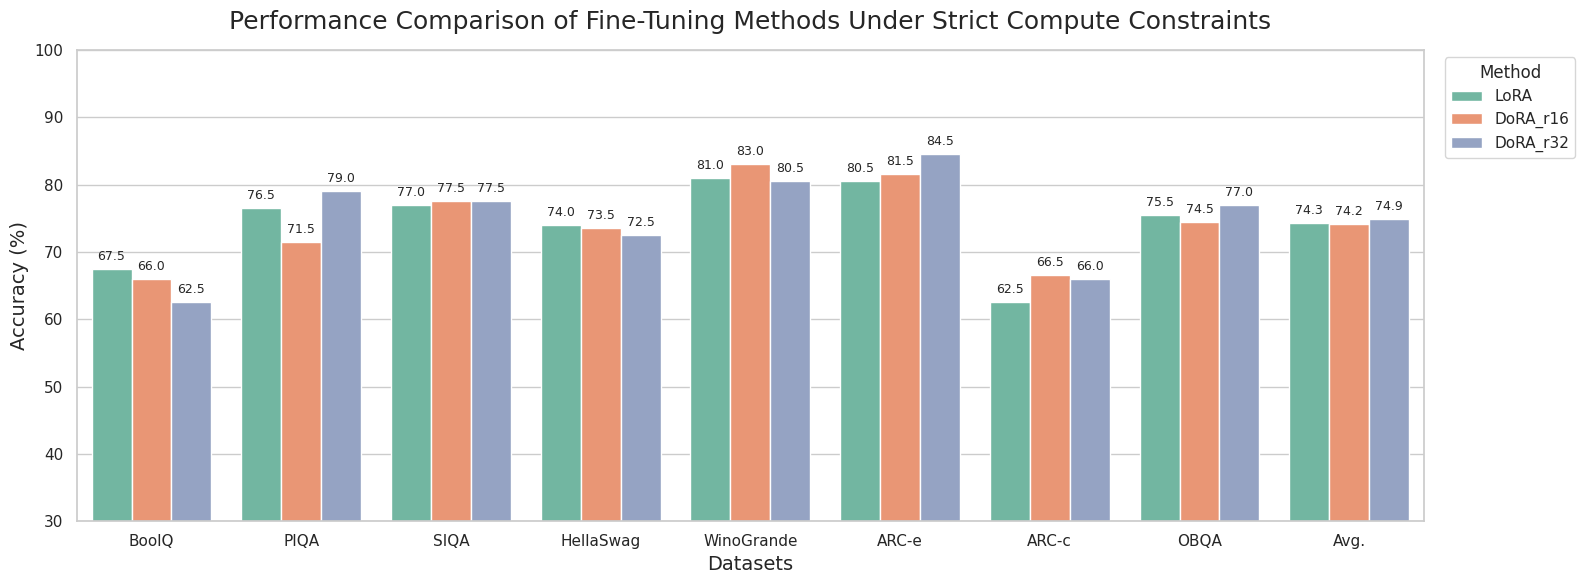

📊 Chart successfully saved to: /content/drive/MyDrive/DoRA/outputs_table15_0430/method_comparison_chart.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Read the final results from CSV
df = pd.read_csv(csv_path)

# Convert from wide format to long format for Seaborn compatibility
tasks = ['BoolQ', 'PIQA', 'SIQA', 'HellaSwag', 'WinoGrande', 'ARC-e', 'ARC-c', 'OBQA', 'Avg.']
df_melted = df.melt(id_vars=['Method'], value_vars=tasks, var_name='Task', value_name='Accuracy')

# Configure plot aesthetics
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# Plot the grouped bar chart
ax = sns.barplot(data=df_melted, x='Task', y='Accuracy', hue='Method', palette='Set2')

# Refine chart details and labels
plt.title('Performance Comparison of Fine-Tuning Methods Under Strict Compute Constraints', fontsize=18, pad=15)
plt.ylabel('Accuracy (%)', fontsize=14)
plt.xlabel('Datasets', fontsize=14)
plt.ylim(30, 100) # Adjust Y-axis baseline to emphasize differences
plt.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')

# Annotate each bar with its exact numerical value
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.1f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 9), textcoords='offset points', fontsize=9)

plt.tight_layout()
out_img_path = OUTPUT_ROOT / 'method_comparison_chart.png'
plt.savefig(out_img_path, dpi=300)
plt.show()

print(f"📊 Chart successfully saved to: {out_img_path}")

### Figure 2 Reproduction: Weight Decomposition Analysis

In [19]:
import sys
sys.path.append(str(DORA_ROOT))

import importlib
import dora_weight_decomposition_analysis

importlib.reload(dora_weight_decomposition_analysis)

<module 'dora_weight_decomposition_analysis' from '/content/drive/MyDrive/DoRA/dora_weight_decomposition_analysis.py'>

In [24]:
import gc
import math
import peft
import random
import time
import torch
import pandas as pd

from pathlib import Path
from IPython.display import display
from peft import get_peft_model, LoraConfig
from transformers import AutoModelForCausalLM, get_linear_schedule_with_warmup
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from dora_weight_decomposition_analysis import (
    AnalysisRunSpec,
    plot_weight_decomposition_triptych,
    plot_weight_decomposition_stacked,
    snapshot_update_steps,
    save_ft_or_lora_snapshot,
)

WD5K_TRAIN_SAMPLES = 5000
WD5K_EVAL_SAMPLES = MAX_EVAL_SAMPLES
# WD5K_FT_LR = 2e-5
WD5K_LORA_LR = 3e-4
WD5K_DORA_LR = 2e-4
WD5K_DORA_RANK = 16
WD5K_DORA_ALPHA = 32

WD5K_ROOT = DORA_ROOT / 'WD_figure2_5k'
WD5K_ROOT.mkdir(parents=True, exist_ok=True)
WD5K_CHECKPOINT_ROOT = WD5K_ROOT / 'checkpoints'
WD5K_CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)
WD5K_SNAPSHOT_ROOT = WD5K_ROOT / 'snapshots'
WD5K_SNAPSHOT_ROOT.mkdir(parents=True, exist_ok=True)
WD5K_OUTPUT_ROOT = OUTPUT_ROOT / 'figure2_5k'
WD5K_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
WD5K_EVAL_ROOT = WD5K_OUTPUT_ROOT / 'evaluations'
WD5K_EVAL_ROOT.mkdir(parents=True, exist_ok=True)

# WD5K_FT_DIR = WD5K_SNAPSHOT_ROOT / 'ft'
WD5K_LORA_DIR = WD5K_SNAPSHOT_ROOT / 'lora'
WD5K_DORA_DIR = WD5K_SNAPSHOT_ROOT / 'dora'
for p in (WD5K_LORA_DIR, WD5K_DORA_DIR):
    p.mkdir(parents=True, exist_ok=True)

# WD5K_FT_STEPS = [
#     WD5K_FT_DIR / 'step1',
#     WD5K_FT_DIR / 'step2',
#     WD5K_FT_DIR / 'step3',
#     WD5K_FT_DIR / 'final',
# ]
WD5K_LORA_STEPS = [
    WD5K_LORA_DIR / 'step1',
    WD5K_LORA_DIR / 'step2',
    WD5K_LORA_DIR / 'step3',
    WD5K_LORA_DIR / 'final',
]
WD5K_DORA_STEPS = [
    WD5K_DORA_DIR / 'step1.pt',
    WD5K_DORA_DIR / 'step2.pt',
    WD5K_DORA_DIR / 'step3.pt',
    WD5K_DORA_DIR / 'final.pt',
]

WD5K_LORA_FINAL_SNAPSHOT = WD5K_LORA_STEPS[-1]
WD5K_DORA_FINAL_SNAPSHOT = WD5K_DORA_STEPS[-1]

WD5K_EXPERIMENTS = {
    # 'FT': {
    #     'type': 'ft',
    #     'lr': WD5K_FT_LR,
    # },
    'LoRA': {
        'type': 'peft',
        'lr': WD5K_LORA_LR,
        'config': LoraConfig(
            task_type='CAUSAL_LM',
            r=8,
            lora_alpha=16,
            target_modules=['q_proj', 'v_proj'],
            lora_dropout=DROPOUT,
            bias='none',
        ),
    },
    'DoRA': {
        'type': 'dora',
        'lr': WD5K_DORA_LR,
        'rank': WD5K_DORA_RANK,
        'alpha': WD5K_DORA_ALPHA,
    },
}

print('WD5K_ROOT:', WD5K_ROOT)
print('WD5K_OUTPUT_ROOT:', WD5K_OUTPUT_ROOT)
print('WD5K_EVAL_ROOT:', WD5K_EVAL_ROOT)
print('WD5K_TRAIN_SAMPLES:', WD5K_TRAIN_SAMPLES)
print('WD5K_EVAL_SAMPLES:', WD5K_EVAL_SAMPLES)
print('WD5K_LORA_STEPS:', WD5K_LORA_STEPS)
print('WD5K_DORA_STEPS:', WD5K_DORA_STEPS)

WD5K_ROOT: /content/drive/MyDrive/DoRA/WD_figure2_5k
WD5K_OUTPUT_ROOT: /content/drive/MyDrive/DoRA/outputs_table15_0430/figure2_5k
WD5K_EVAL_ROOT: /content/drive/MyDrive/DoRA/outputs_table15_0430/figure2_5k/evaluations
WD5K_TRAIN_SAMPLES: 5000
WD5K_EVAL_SAMPLES: 200
WD5K_LORA_STEPS: [PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/lora/step1'), PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/lora/step2'), PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/lora/step3'), PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/lora/final')]
WD5K_DORA_STEPS: [PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/step1.pt'), PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/step2.pt'), PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/step3.pt'), PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/final.pt')]


In [21]:
def wd5k_method_slug(method_name: str) -> str:
    return re.sub(r'[^a-zA-Z0-9._-]+', '_', method_name)


In [22]:
def wd5k_load_train_examples(max_train_samples: int = WD5K_TRAIN_SAMPLES):
    examples = []
    for task, dirname in TASK_DIRS.items():
        path = DATA_ROOT / dirname / 'train.json'
        task_examples = load_json_list(path)
        for ex in task_examples:
            ex = dict(ex)
            ex['task'] = task
            examples.append(ex)
    random.Random(SEED).shuffle(examples)
    if max_train_samples is not None:
        examples = examples[:max_train_samples]
    print('WD5K total train examples:', len(examples))
    return examples


def wd5k_build_train_loader(tokenizer, max_train_samples: int = WD5K_TRAIN_SAMPLES):
    train_examples = wd5k_load_train_examples(max_train_samples=max_train_samples)
    dataset = SFTDataset(train_examples, tokenizer, MAX_LENGTH)
    loader = DataLoader(
        dataset,
        batch_size=MICRO_BATCH_SIZE,
        shuffle=True,
        collate_fn=make_collator(tokenizer),
        num_workers=2,
        pin_memory=True,
    )
    return loader


# def wd5k_load_full_ft_model(base_model: str):
#     dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16
#     model = AutoModelForCausalLM.from_pretrained(
#         base_model,
#         torch_dtype=dtype,
#         device_map='auto',
#         low_cpu_mem_usage=True,
#     )
#     if hasattr(model, 'config'):
#         model.config.use_cache = False
#     model.gradient_checkpointing_enable()
#     if hasattr(model, 'enable_input_require_grads'):
#         model.enable_input_require_grads()
#     for p in model.parameters():
#         p.requires_grad = True
#     return model


def wd5k_has_peft_checkpoint(path: Path) -> bool:
    return path.exists() and (path / 'adapter_config.json').exists()


# def wd5k_has_full_checkpoint(path: Path) -> bool:
#     return path.exists() and (path / 'config.json').exists()


def wd5k_method_slug(method_name: str) -> str:
    return re.sub(r'[^a-zA-Z0-9._-]+', '_', method_name)


def wd5k_snapshot_exists(path: Path, kind: str) -> bool:
    path = Path(path)
    if kind == 'peft':
        return path.exists() and (path / 'adapter_config.json').exists()
    if kind == 'dora':
        return path.exists()
    raise ValueError(f'Unsupported snapshot kind: {kind}')


def wd5k_existing_snapshot_paths(snapshot_paths, kind: str):
    return [Path(path) for path in snapshot_paths if wd5k_snapshot_exists(Path(path), kind)]


def wd5k_has_all_snapshots(snapshot_paths, kind: str) -> bool:
    snapshot_paths = list(snapshot_paths or [])
    return bool(snapshot_paths) and len(wd5k_existing_snapshot_paths(snapshot_paths, kind)) == len(snapshot_paths)


def wd5k_eval_csv_path(method_name: str) -> Path:
    return WD5K_EVAL_ROOT / f'{wd5k_method_slug(method_name)}_eval.csv'


def wd5k_load_cached_eval(method_name: str):
    eval_path = wd5k_eval_csv_path(method_name)
    if not eval_path.exists():
        return None
    eval_df = pd.read_csv(eval_path)
    print(f'Using cached WD5K evaluation CSV: {eval_path}')
    return eval_df


def wd5k_cached_eval_to_acc_dict(eval_df: pd.DataFrame):
    return {str(row['Task']): float(row['Accuracy']) for _, row in eval_df.iterrows()}


def wd5k_cached_eval_params_pct(eval_df: pd.DataFrame) -> float:
    return float(eval_df['# Params (%)'].iloc[0])


def wd5k_save_eval_csv(method_name: str, acc_dict, actual_pct: float, setup: dict):
    eval_rows = [
        {
            'Method': method_name,
            'Task': task,
            'Accuracy': value,
            'Train Samples': WD5K_TRAIN_SAMPLES,
            'Eval Samples': WD5K_EVAL_SAMPLES,
            '# Params (%)': round(actual_pct, 4),
            'Rank': setup.get('rank', ''),
        }
        for task, value in acc_dict.items()
    ]
    eval_df = pd.DataFrame(eval_rows)
    eval_path = WD5K_EVAL_ROOT / f'{wd5k_method_slug(method_name)}_eval.csv'
    eval_df.to_csv(eval_path, index=False)
    print(f'Saved WD5K evaluation CSV: {eval_path}')
    return eval_path


def wd5k_save_snapshot_from_loaded_model(model, snapshot_path: Path, snapshot_kind: str, snapshot_rank: int = None):
    snapshot_path = Path(snapshot_path)
    if wd5k_snapshot_exists(snapshot_path, snapshot_kind):
        return
    if snapshot_kind == 'peft':
        save_ft_or_lora_snapshot(model, snapshot_path)
    elif snapshot_kind == 'dora':
        if snapshot_rank is None:
            raise ValueError('DoRA snapshot saving requires snapshot_rank.')
        save_dora_adapter(model, snapshot_path, rank=snapshot_rank)
    else:
        raise ValueError(f'Unsupported snapshot kind: {snapshot_kind}')
    print(f'Backfilled final WD5K snapshot without retraining: {snapshot_path}')


def wd5k_train_model(
    model,
    tokenizer,
    method_name: str,
    lr: float,
    max_train_samples: int = WD5K_TRAIN_SAMPLES,
    snapshot_paths=None,
    snapshot_kind: str = 'peft',
    snapshot_rank: int = None,
):
    loader = wd5k_build_train_loader(tokenizer, max_train_samples=max_train_samples)
    model.train()

    optimizer = torch.optim.AdamW(
        (p for p in model.parameters() if p.requires_grad),
        lr=lr,
        weight_decay=WEIGHT_DECAY,
    )
    update_steps_per_epoch = math.ceil(len(loader) / GRADIENT_ACCUMULATION_STEPS)
    total_update_steps = EPOCHS * update_steps_per_epoch
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=WARMUP_STEPS,
        num_training_steps=total_update_steps,
    )

    snapshot_paths = list(snapshot_paths or [])
    snapshot_save_steps = []
    if snapshot_paths:
        snapshot_save_steps = snapshot_update_steps(total_update_steps, num_intermediate=len(snapshot_paths) - 1)
        print(f'WD5K {method_name} snapshot schedule: {list(zip(snapshot_save_steps, snapshot_paths))}')
    next_snapshot_idx = 0

    global_step = 0
    running_loss = 0.0
    start_time = time.time()
    optimizer.zero_grad(set_to_none=True)

    for epoch in range(EPOCHS):
        pbar = tqdm(loader, desc=f'WD5K Training {method_name} | Epoch {epoch + 1}/{EPOCHS}')
        for step, batch in enumerate(pbar):
            batch = {k: v.to(model.device) for k, v in batch.items()}
            out = model(**batch)
            loss = out.loss / GRADIENT_ACCUMULATION_STEPS
            loss.backward()
            running_loss += float(loss.detach().cpu())

            if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (step + 1) == len(loader):
                torch.nn.utils.clip_grad_norm_(
                    (p for p in model.parameters() if p.requires_grad),
                    MAX_GRAD_NORM,
                )
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)
                global_step += 1

                while next_snapshot_idx < len(snapshot_save_steps) and global_step >= snapshot_save_steps[next_snapshot_idx]:
                    snapshot_path = Path(snapshot_paths[next_snapshot_idx])
                    if snapshot_kind == 'peft':
                        save_ft_or_lora_snapshot(model, snapshot_path)
                    elif snapshot_kind == 'dora':
                        if snapshot_rank is None:
                            raise ValueError('DoRA snapshot saving requires snapshot_rank.')
                        save_dora_adapter(model, snapshot_path, rank=snapshot_rank)
                    else:
                        raise ValueError(f'Unsupported snapshot_kind: {snapshot_kind}')
                    print(f'WD5K saved {method_name} snapshot at update {global_step}: {snapshot_path}')
                    next_snapshot_idx += 1

                if global_step % 10 == 0:
                    pbar.set_postfix({'loss': running_loss / 10, 'lr': scheduler.get_last_lr()[0]})
                    running_loss = 0.0

    print(f'WD5K {method_name} finished in {(time.time() - start_time) / 60:.1f} min.')
    return model


def wd5k_run_figure2_suite(force_retrain: bool = False):
    tokenizer = load_tokenizer(BASE_MODEL)
    results = []

    # ft_final_dir = WD5K_CHECKPOINT_ROOT / 'ft_final'
    lora_final_dir = WD5K_CHECKPOINT_ROOT / 'lora_final'
    dora_final_path = WD5K_CHECKPOINT_ROOT / 'dora_final.pt'

    for method_name, setup in WD5K_EXPERIMENTS.items():
        print('\n' + '=' * 90)
        print(f'WD5K starting experiment: {method_name}')

        cached_eval_df = None if force_retrain else wd5k_load_cached_eval(method_name)

        # if setup['type'] == 'ft':
        #     ...
        if setup['type'] == 'peft':
            base_model = AutoModelForCausalLM.from_pretrained(
                BASE_MODEL,
                torch_dtype=torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16,
                device_map='auto',
                low_cpu_mem_usage=True,
            )

            lora_has_final_checkpoint = wd5k_has_peft_checkpoint(lora_final_dir)
            lora_has_all_snapshots = wd5k_has_all_snapshots(WD5K_LORA_STEPS, kind='peft')

            if cached_eval_df is not None and (lora_has_final_checkpoint or lora_has_all_snapshots):
                print(f'Skipping WD5K LoRA evaluation because cached metrics already exist.')
                model = None
            elif lora_has_final_checkpoint and not force_retrain:
                print(f'Loading existing WD5K LoRA checkpoint: {lora_final_dir}')
                model = peft.PeftModel.from_pretrained(base_model, lora_final_dir, is_trainable=False)
                wd5k_save_snapshot_from_loaded_model(model, WD5K_LORA_FINAL_SNAPSHOT, snapshot_kind='peft')
            elif lora_has_all_snapshots and not force_retrain:
                print(f'Loading existing WD5K LoRA final snapshot: {WD5K_LORA_FINAL_SNAPSHOT}')
                model = peft.PeftModel.from_pretrained(base_model, WD5K_LORA_FINAL_SNAPSHOT, is_trainable=False)
            else:
                model = get_peft_model(base_model, setup['config'])
                model = wd5k_train_model(
                    model,
                    tokenizer,
                    method_name,
                    setup['lr'],
                    max_train_samples=WD5K_TRAIN_SAMPLES,
                    snapshot_paths=WD5K_LORA_STEPS,
                    snapshot_kind='peft',
                )
                model.save_pretrained(lora_final_dir)
                print(f'Saved WD5K LoRA final checkpoint to: {lora_final_dir}')

        else:
            dora_has_final_checkpoint = dora_final_path.exists()
            dora_has_all_snapshots = wd5k_has_all_snapshots(WD5K_DORA_STEPS, kind='dora')

            if cached_eval_df is not None and (dora_has_final_checkpoint or dora_has_all_snapshots):
                print(f'Skipping WD5K DoRA evaluation because cached metrics already exist.')
                model = None
            else:
                model = load_dora_model(BASE_MODEL, rank=setup['rank'])
                if dora_has_final_checkpoint and not force_retrain:
                    print(f'Loading existing WD5K DoRA checkpoint: {dora_final_path}')
                    model = load_dora_adapter(model, dora_final_path)
                    wd5k_save_snapshot_from_loaded_model(
                        model,
                        WD5K_DORA_FINAL_SNAPSHOT,
                        snapshot_kind='dora',
                        snapshot_rank=setup['rank'],
                    )
                elif dora_has_all_snapshots and not force_retrain:
                    print(f'Loading existing WD5K DoRA final snapshot: {WD5K_DORA_FINAL_SNAPSHOT}')
                    model = load_dora_adapter(model, WD5K_DORA_FINAL_SNAPSHOT)
                else:
                    model = wd5k_train_model(
                        model,
                        tokenizer,
                        method_name,
                        setup['lr'],
                        max_train_samples=WD5K_TRAIN_SAMPLES,
                        snapshot_paths=WD5K_DORA_STEPS,
                        snapshot_kind='dora',
                        snapshot_rank=setup['rank'],
                    )
                    save_dora_adapter(model, dora_final_path, rank=setup['rank'])
                    print(f'Saved WD5K DoRA final checkpoint to: {dora_final_path}')

        if cached_eval_df is not None:
            acc_dict = wd5k_cached_eval_to_acc_dict(cached_eval_df)
            actual_pct = wd5k_cached_eval_params_pct(cached_eval_df)
        else:
            trainable, total, actual_pct = trainable_parameter_summary(model)
            print(f'WD5K evaluating {method_name}...')
            acc_dict = evaluate_all_tasks(model, tokenizer, rank=f'wd5k_{wd5k_method_slug(method_name)}')
            wd5k_save_eval_csv(method_name, acc_dict, actual_pct, setup)

        row = table_row_from_accuracies(rank=setup.get('rank', 0), accuracies=acc_dict)
        row['Method'] = method_name
        row['Train Samples'] = WD5K_TRAIN_SAMPLES
        row['Eval Samples'] = WD5K_EVAL_SAMPLES
        row['# Params (%)'] = round(actual_pct, 4)
        results.append(row)
        pd.DataFrame(results).to_csv(WD5K_OUTPUT_ROOT / 'wd5k_results.csv', index=False)

        if model is not None:
            del model
        if setup['type'] == 'peft':
            del base_model
        gc.collect()
        torch.cuda.empty_cache()

    lora_analysis_paths = wd5k_existing_snapshot_paths(WD5K_LORA_STEPS, kind='peft') or [lora_final_dir]
    dora_analysis_paths = wd5k_existing_snapshot_paths(WD5K_DORA_STEPS, kind='dora') or [dora_final_path]

    print('WD5K LoRA analysis checkpoints:', lora_analysis_paths)
    print('WD5K DoRA analysis checkpoints:', dora_analysis_paths)

    specs = [
        AnalysisRunSpec(
            name='LoRA',
            kind='lora',
            checkpoints=lora_analysis_paths,
        ),
        AnalysisRunSpec(
            name='DoRA',
            kind='dora',
            checkpoints=dora_analysis_paths,
            rank=WD5K_DORA_RANK,
            alpha=WD5K_DORA_ALPHA,
            target_modules=['q_proj', 'v_proj'],
        ),
    ]

    fig, points_by_suffix = plot_weight_decomposition_stacked(
        base_model=BASE_MODEL,
        specs=specs,
        target_suffixes=('q_proj', 'v_proj'),
        output_path=WD5K_OUTPUT_ROOT / 'weight_decomposition_stacked.png',
        title='Weight decomposition analysis (5k training samples)',
        figsize=(16, 10),
        y_padding_ratio=0.25,
    )

    q_points = points_by_suffix['q_proj']
    v_points = points_by_suffix['v_proj']
    pd.DataFrame(q_points).to_csv(WD5K_OUTPUT_ROOT / 'weight_decomposition_qproj_points.csv', index=False)
    pd.DataFrame(v_points).to_csv(WD5K_OUTPUT_ROOT / 'weight_decomposition_vproj_points.csv', index=False)

    results_df = pd.DataFrame(results)
    display(results_df)
    return results_df, q_points, v_points, fig


WD5K starting experiment: DoRA


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Rank 16: replaced 160 linear layers
Rank 16: trainable 28,925,952 / 6,767,341,568 = 0.43%
WD5K total train examples: 5000
WD5K DoRA snapshot schedule: [(235, PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/step1.pt')), (470, PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/step2.pt')), (704, PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/step3.pt')), (939, PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/final.pt'))]


WD5K Training DoRA | Epoch 1/3:   0%|          | 0/5000 [00:00<?, ?it/s]

Saved adapter: /content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/step1.pt
WD5K saved DoRA snapshot at update 235: /content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/step1.pt


...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

,Method,rank r,# Params (%),BoolQ,PIQA,SIQA,HellaSwag,WinoGrande,ARC-e,ARC-c,OBQA,Avg.,Train Samples,Eval Samples
0,DoRA,16,0.4274,68.0,77.5,78.0,73.0,78.5,82.5,62.0,68.0,73.4,5000,200


/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:152: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


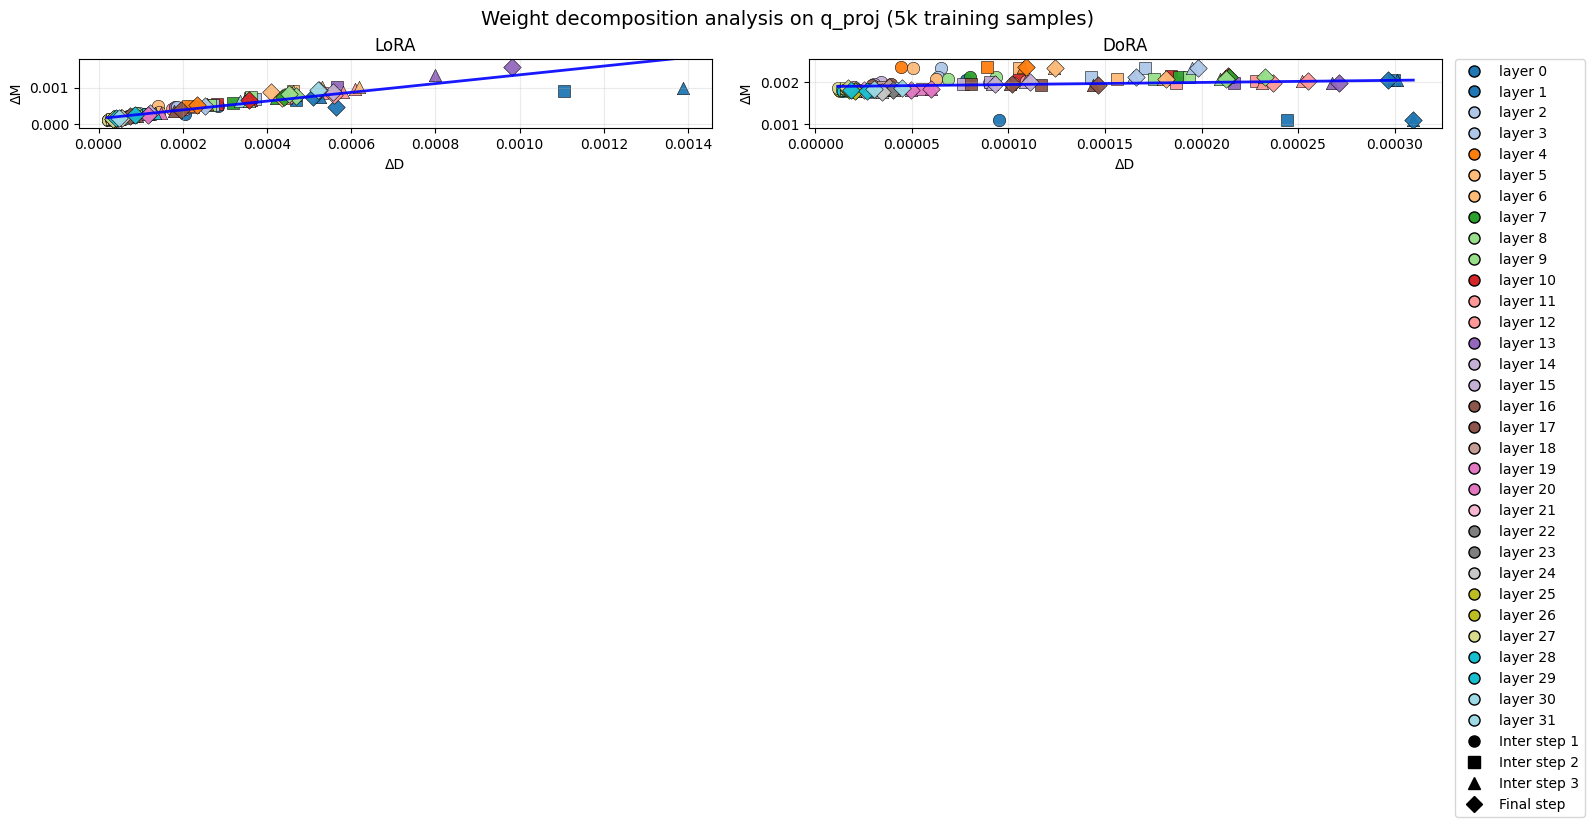

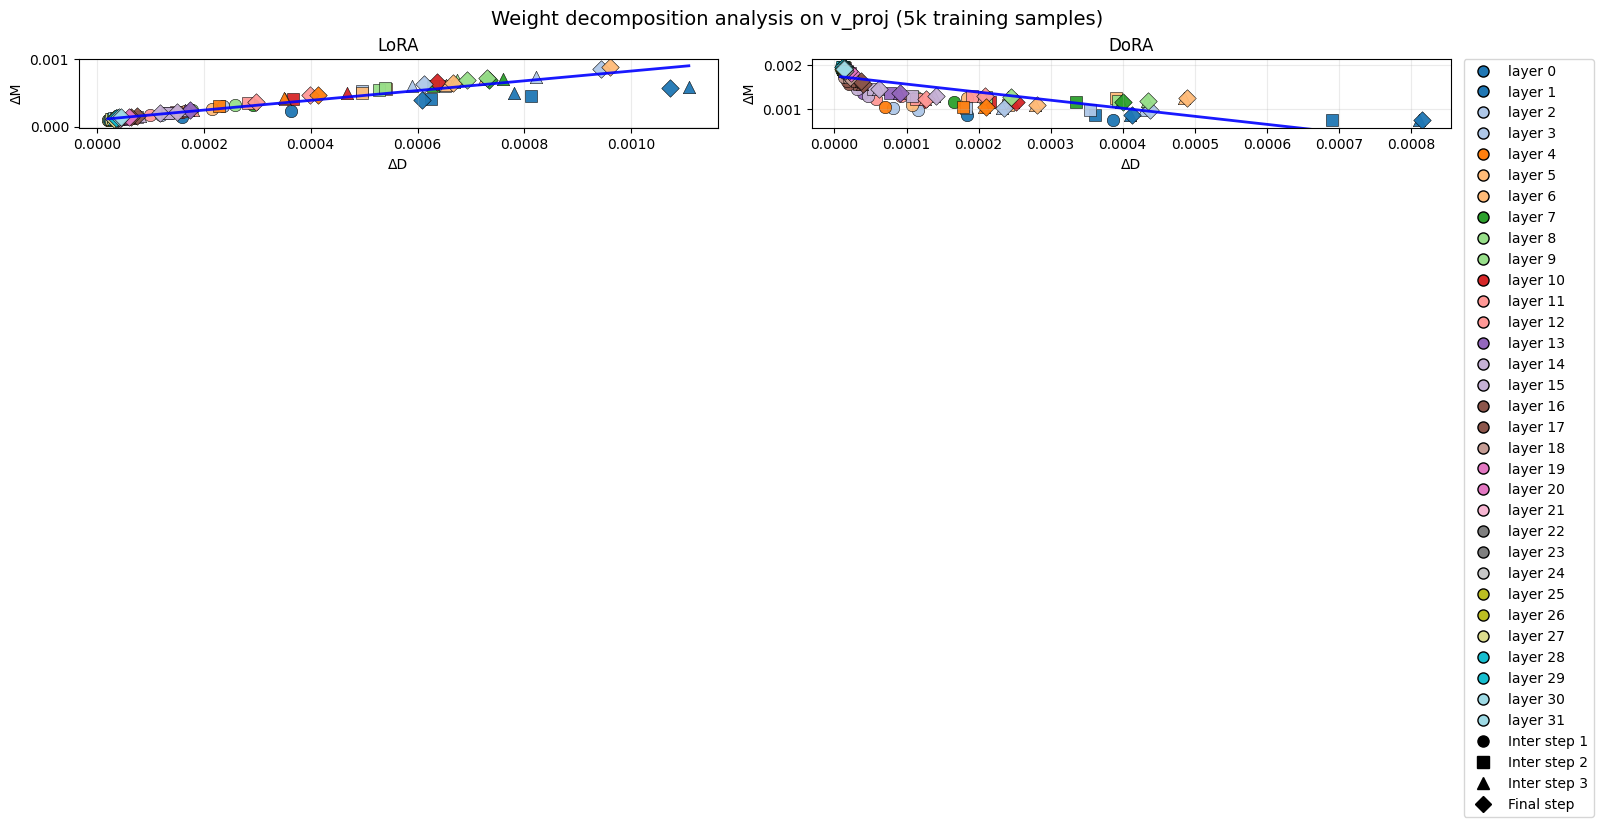

In [ ]:
wd5k_results_df, wd5k_q_points, wd5k_v_points, wd5k_fig_q, wd5k_fig_v = wd5k_run_figure2_suite(force_retrain=True)


WD5K starting experiment: LoRA
Using cached WD5K evaluation CSV: /content/drive/MyDrive/DoRA/outputs_table15_0430/figure2_5k/evaluations/LoRA_eval.csv


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Skipping WD5K LoRA evaluation because cached metrics already exist.

WD5K starting experiment: DoRA
Using cached WD5K evaluation CSV: /content/drive/MyDrive/DoRA/outputs_table15_0430/figure2_5k/evaluations/DoRA_eval.csv
Skipping WD5K DoRA evaluation because cached metrics already exist.
WD5K LoRA analysis checkpoints: [PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/lora/step1'), PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/lora/step2'), PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/lora/step3'), PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/lora/final')]
WD5K DoRA analysis checkpoints: [PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/step1.pt'), PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/step2.pt'), PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/step3.pt'), PosixPath('/content/drive/MyDrive/DoRA/WD_figure2_5k/snapshots/dora/final.pt')]


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

...

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

,Method,rank r,# Params (%),BoolQ,PIQA,SIQA,HellaSwag,WinoGrande,ARC-e,ARC-c,OBQA,Avg.,Train Samples,Eval Samples
0,LoRA,0,0.0000,73.5,74.0,74.0,67.5,75.0,81.5,63.0,69.5,72.2,5000,200
1,DoRA,16,0.4274,68.0,77.5,78.0,73.0,78.5,82.5,62.0,68.0,73.4,5000,200


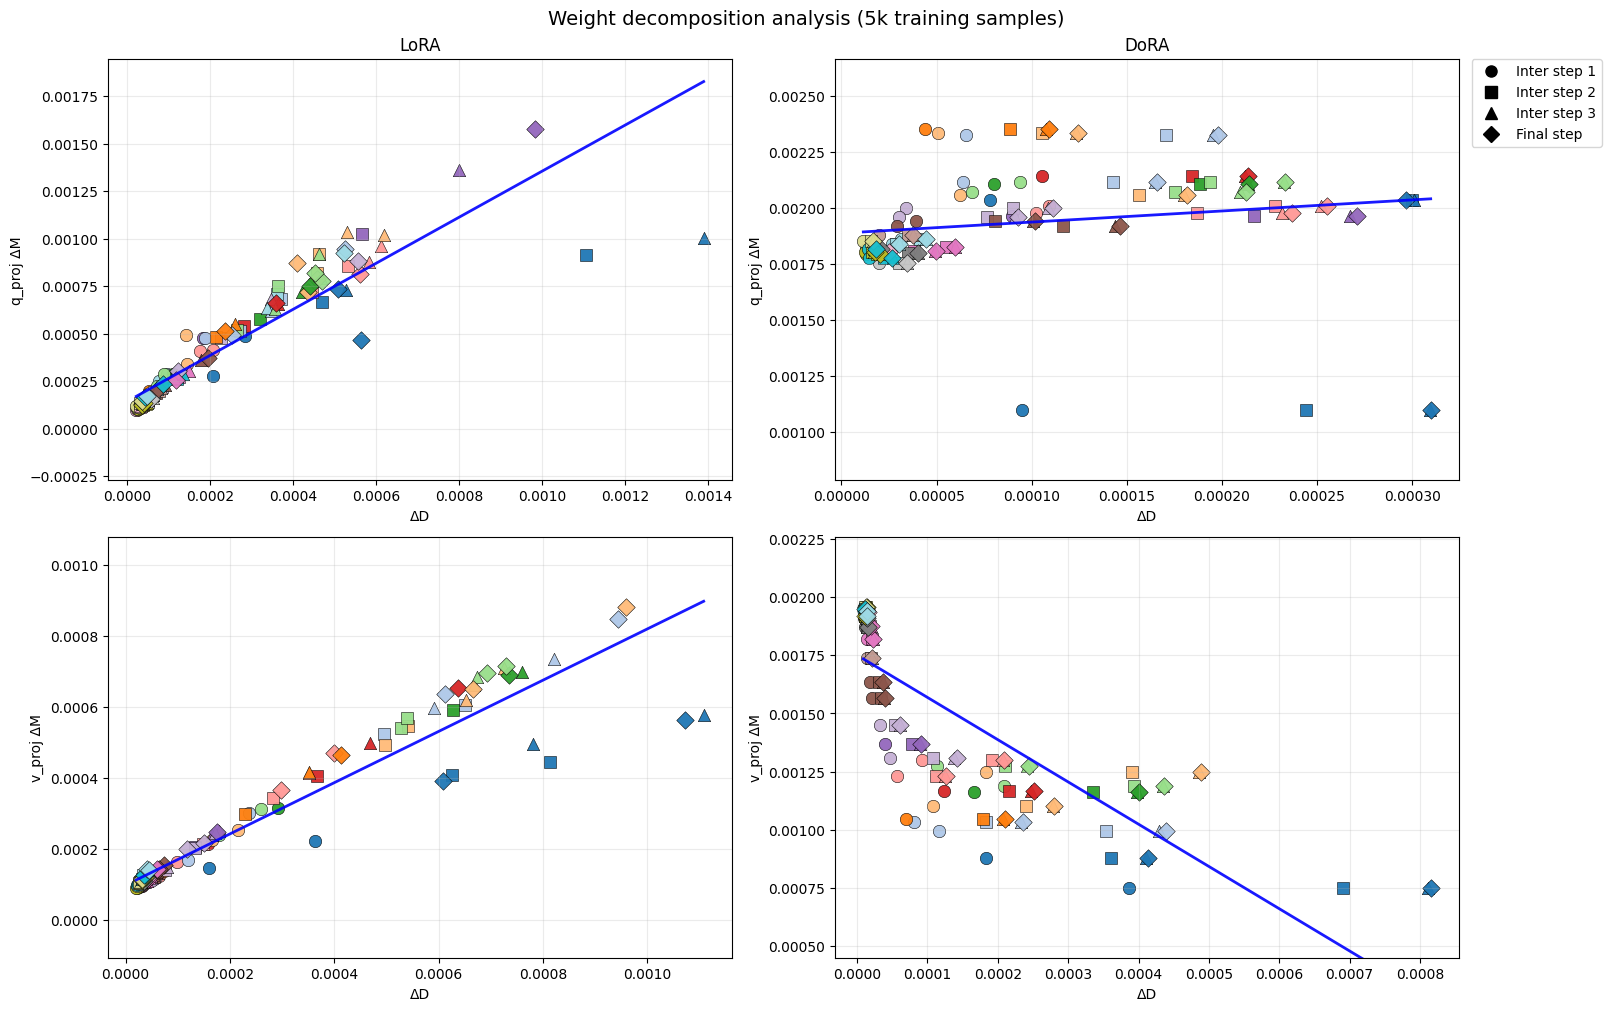

In [25]:
wd5k_results_df, wd5k_q_points, wd5k_v_points, wd5k_fig = wd5k_run_figure2_suite(force_retrain=False)